In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def modified_dbscan(X, core_indices, eps, min_samples):
    labels = -np.ones(len(X))  # Initialize all points as noise
    cluster_id = 0

    for idx in core_indices:
        if labels[idx] != -1:  # Skip if already processed
            continue

        # Find neighbors
        neighbors = np.where(np.linalg.norm(X - X[idx], axis=1) < eps)[0]

        if len(neighbors) < min_samples:
            labels[idx] = -1  # Still noise, but this is redundant
        else:
            labels[idx] = cluster_id
            expand_cluster(X, labels, cluster_id, neighbors, eps, min_samples)
            cluster_id += 1

    return labels

def expand_cluster(X, labels, cluster_id, neighbors, eps, min_samples):
    i = 0
    while i < len(neighbors):
        neighbor_idx = neighbors[i]

        if labels[neighbor_idx] == -1:  # Noise
            labels[neighbor_idx] = cluster_id

        elif labels[neighbor_idx] == -2:  # Unclassified
            labels[neighbor_idx] = cluster_id
            new_neighbors = np.where(np.linalg.norm(X - X[neighbor_idx], axis=1) < eps)[0]
            if len(new_neighbors) >= min_samples:
                neighbors = np.append(neighbors, new_neighbors)  # Append new neighbors

        i += 1


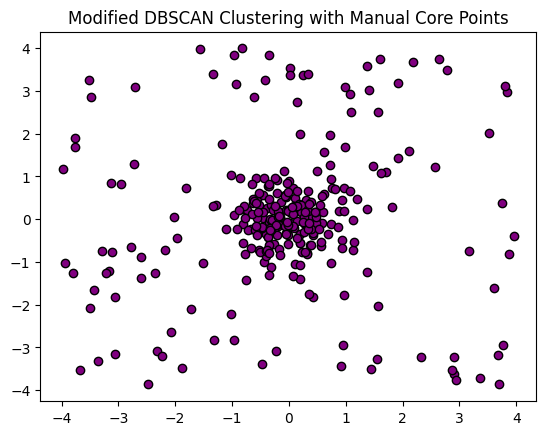

In [3]:
# Generate sample data with a dense zone in the middle and outliers around
np.random.seed(0)
n_samples = 300
X_center = 0.5 * np.random.randn(int(0.6 * n_samples), 2)
X_outliers = np.random.uniform(low=-4, high=4, size=(int(0.4 * n_samples), 2))
X = np.vstack((X_center, X_outliers))

plt.scatter(X[:, 0], X[:, 1], c=["purple"], edgecolors='k', marker='o')
plt.title("Modified DBSCAN Clustering with Manual Core Points")
plt.show()

In [ ]:
core_indices = np.random.choice(len(X_center), size=1, replace=False)
core_indices[0] = core_indices[0]

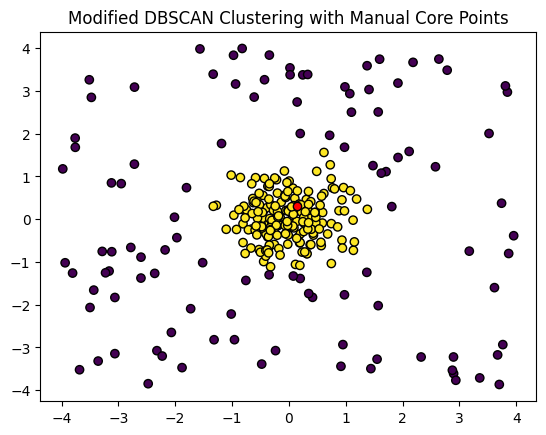

In [33]:
eps = 1.5
min_samples = 0

labels = modified_dbscan(X, core_indices, eps, min_samples)
np.append(labels, "red")

plt.scatter(X[:, 0], X[:, 1], c=labels, edgecolors='k', marker='o')
plt.scatter(X[core_indices, 0], X[core_indices, 1], c='red', edgecolors='k', marker='o')
plt.title("Modified DBSCAN Clustering with Manual Core Points")
plt.show()

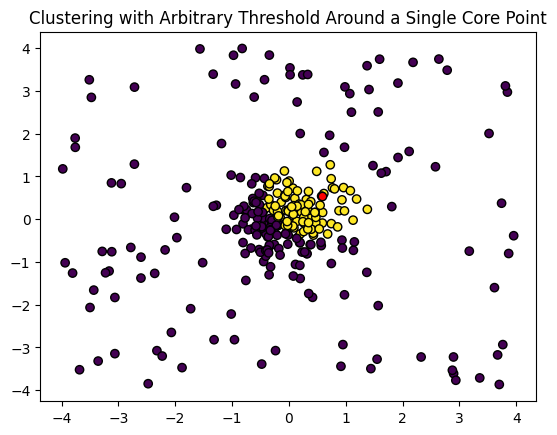

In [36]:
# %%
# Perform clustering using an arbitrary threshold around a single core point
threshold = 1
labels_threshold = -np.ones(len(X))  # Initialize all points as noise
cluster_id = 0

# Find neighbors of the core point within the threshold
core_point = core_indices[0]
neighbors = np.where(np.linalg.norm(X - X[core_point], axis=1) < threshold)[0]

# Assign the same cluster label to all neighbors
labels_threshold[neighbors] = cluster_id

plt.scatter(X[:, 0], X[:, 1], c=labels_threshold, edgecolors='k', marker='o')
plt.scatter(X[core_point, 0], X[core_point, 1], c='red', edgecolors='k', marker='o')
plt.title("Clustering with Arbitrary Threshold Around a Single Core Point")
plt.show()
